In [ ]:
import poreflow as pf
from poreflow.steps import changepoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from logic.database import AA_CLASS

# df = pd.read_csv('features.csv')

In [ ]:
# data_path = "nanopore_trace_database.csv"

# db = pd.read_csv(data_path)
# SAMPLING_FREQ = 5000 # needs to match what i used to generate

In [ ]:
# trace_id = 0
# trace = db[db['trace_id'] == trace_id]
# current = trace['current_pA'].to_numpy()
# time_ms = trace['time_ms'].to_numpy()


# # steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=0.3, min_level_length=10)
# # print(steps)

In [ ]:
# for s in [1.0, 0.5, 0.3, 0.2, 0.1]:
#     steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=s)
#     print(f"sensitivity={s}: {len(steps)} steps detected (ground truth: 275)")

sensitivity=1.0: 169 steps detected (ground truth: 275)
sensitivity=0.5: 335 steps detected (ground truth: 275)
sensitivity=0.3: 578 steps detected (ground truth: 275)
sensitivity=0.2: 735 steps detected (ground truth: 275)
sensitivity=0.1: 1013 steps detected (ground truth: 275)


In [ ]:
# steps = changepoint.get_steps(current, sfreq=SAMPLING_FREQ, sensitivity=0.3, min_level_length=10)
# print(steps)

     start_idx  end_idx       std        mean  n_pts  start_time  end_time  \
0            0       25  1.431508   89.747254     25      0.0000    0.0050   
1           25       50  1.089605   83.526237     25      0.0050    0.0100   
2           50       81  0.831987   74.437332     31      0.0100    0.0162   
3           81       92  1.204535   75.920356     11      0.0162    0.0184   
4           92      105  0.757269   76.690689     13      0.0184    0.0210   
..         ...      ...       ...         ...    ...         ...       ...   
212       4398     4414  0.803395  110.204042     16      0.8796    0.8828   
213       4414     4433  1.138157  107.612780     19      0.8828    0.8866   
214       4433     4444  0.534740  107.017926     11      0.8866    0.8888   
215       4444     4469  1.043829  100.097114     25      0.8888    0.8938   
216       4469     4494  1.342879   97.148750     25      0.8938    0.8988   

     dwell_time  
0        0.0050  
1        0.0050  
2        

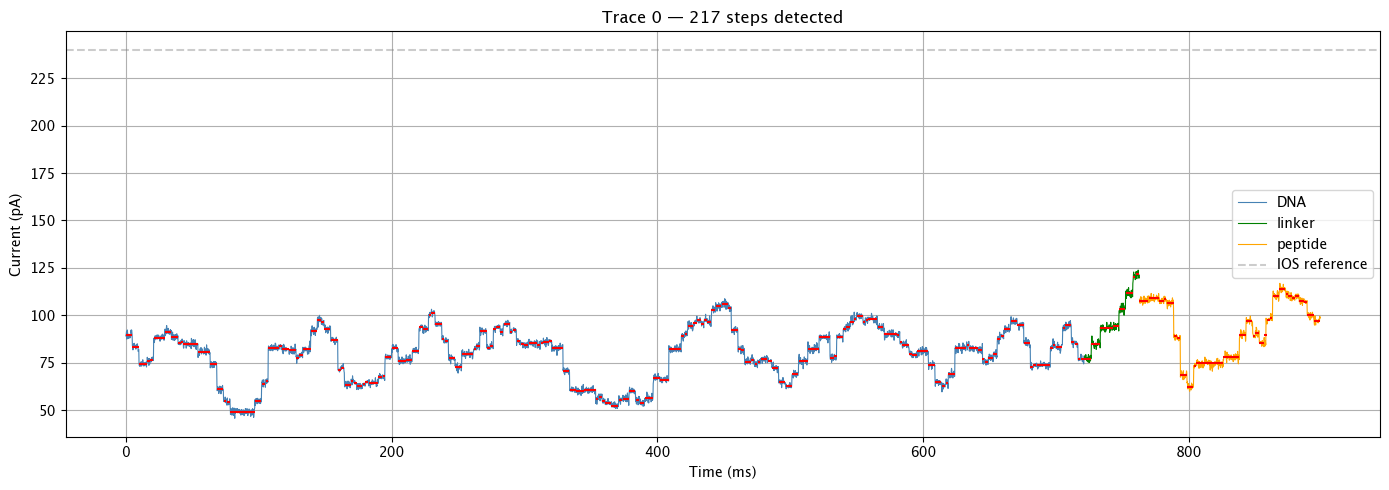

In [23]:
import matplotlib.pyplot as plt
from plot_trace import plot_trace
from logic import steps

fig, ax = plt.subplots(figsize=(14, 5))

plot_trace(steps.db, steps.trace_id, ax=ax)

for _, step in steps.steps.iterrows():
    start = int(step[steps.pf.START_IDX_COL])
    end   = int(step[steps.pf.END_IDX_COL])
    ax.hlines(step[steps.pf.MEAN_COL], steps.time_ms[start], steps.time_ms[end - 1],
              color='red', linewidth=1.5)

ax.set_title(f'Trace {steps.trace_id} — {len(steps.steps)} steps detected')
plt.tight_layout()
plt.show()

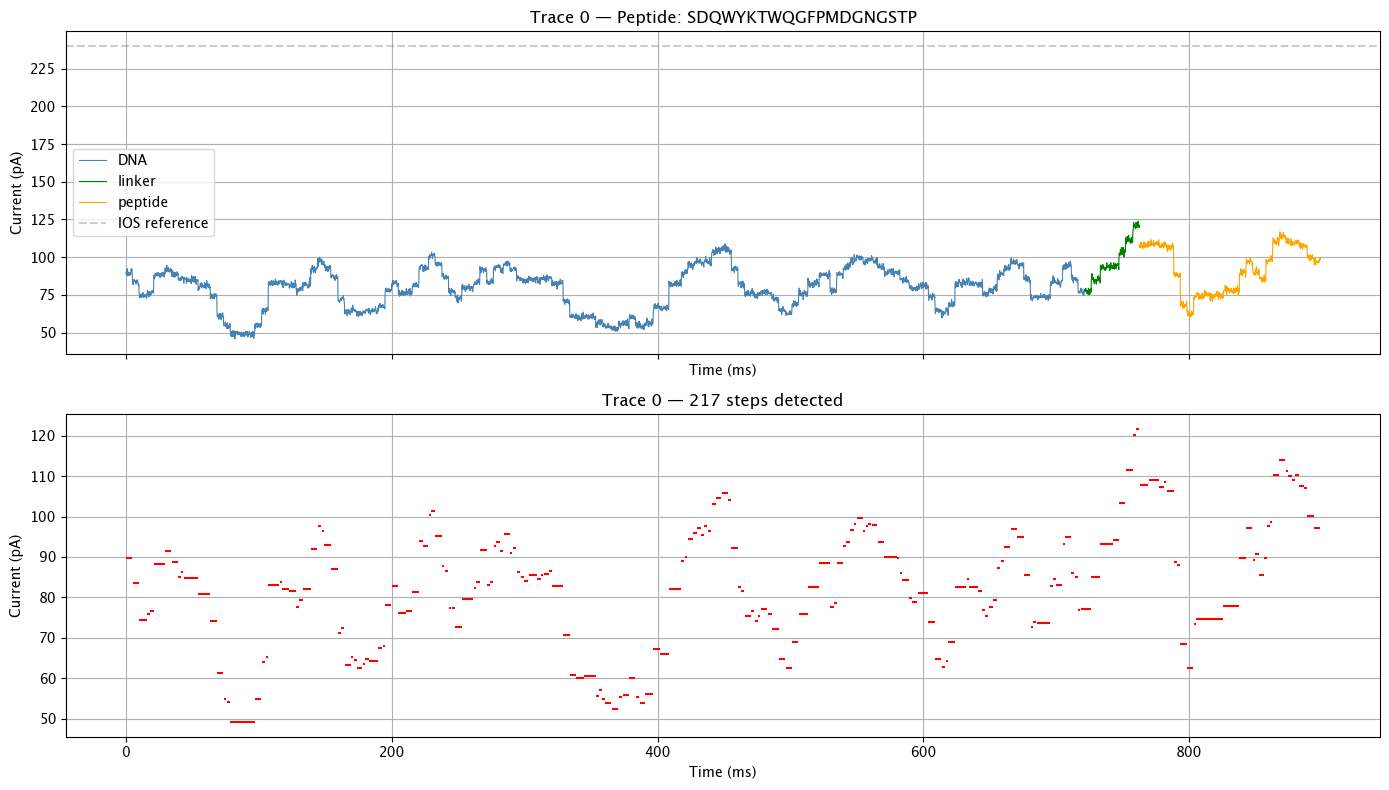

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: raw trace coloured by region
plot_trace(steps.db, steps.trace_id, ax=ax1)

# Bottom: step levels only
for _, step in steps.steps.iterrows():
    start = int(step[steps.pf.START_IDX_COL])
    end   = int(step[steps.pf.END_IDX_COL])
    ax2.hlines(step[steps.pf.MEAN_COL], steps.time_ms[start], steps.time_ms[end - 1],
               color='red', linewidth=1.5)

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Current (pA)')
ax2.set_title(f'Trace {steps.trace_id} — {len(steps.steps)} steps detected')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from logic.database import (
    peptide_to_cdna, simulate_dna_region, simulate_linker_region,
    simulate_peptide_region, IOS, PEP_BASELINE, SAMPLING_FREQ
)

trace_id = 0
trace = steps.db[steps.db['trace_id'] == trace_id]
peptide = trace['peptide_sequence'].iloc[0]

# Recompute clean (noiseless) levels
cdna = peptide_to_cdna(peptide)
dna_clean    = simulate_dna_region(cdna)
linker_clean = simulate_linker_region(dna_clean[-1], PEP_BASELINE * IOS)
pep_clean    = simulate_peptide_region(peptide)

clean_current = np.concatenate([dna_clean, linker_clean, pep_clean])
clean_time_ms = np.arange(len(clean_current)) * (1000 / SAMPLING_FREQ)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

# 1. Noisy trace
plot_trace(steps.db, trace_id, ax=ax1)
ax1.set_title(f'Trace {trace_id} — noisy (from CSV)')

# 2. Clean ground truth
ax2.plot(clean_time_ms, clean_current, color='black', linewidth=0.8)
ax2.set_ylabel('Current (pA)')
ax2.set_title('Clean ground truth (no noise, re-simulated)')
ax2.grid(True)

# 3. Poreflow-detected steps
current = trace['current_pA'].to_numpy()
time_ms = trace['time_ms'].to_numpy()
for _, step in steps.steps.iterrows():
    start = int(step[steps.pf.START_IDX_COL])
    end   = int(step[steps.pf.END_IDX_COL])
    ax3.hlines(step[steps.pf.MEAN_COL], time_ms[start], time_ms[end - 1],
               color='red', linewidth=1.5)
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Current (pA)')
ax3.set_title(f'Poreflow detected steps ({len(steps.steps)} steps)')
ax3.grid(True)

plt.tight_layout()
plt.show()

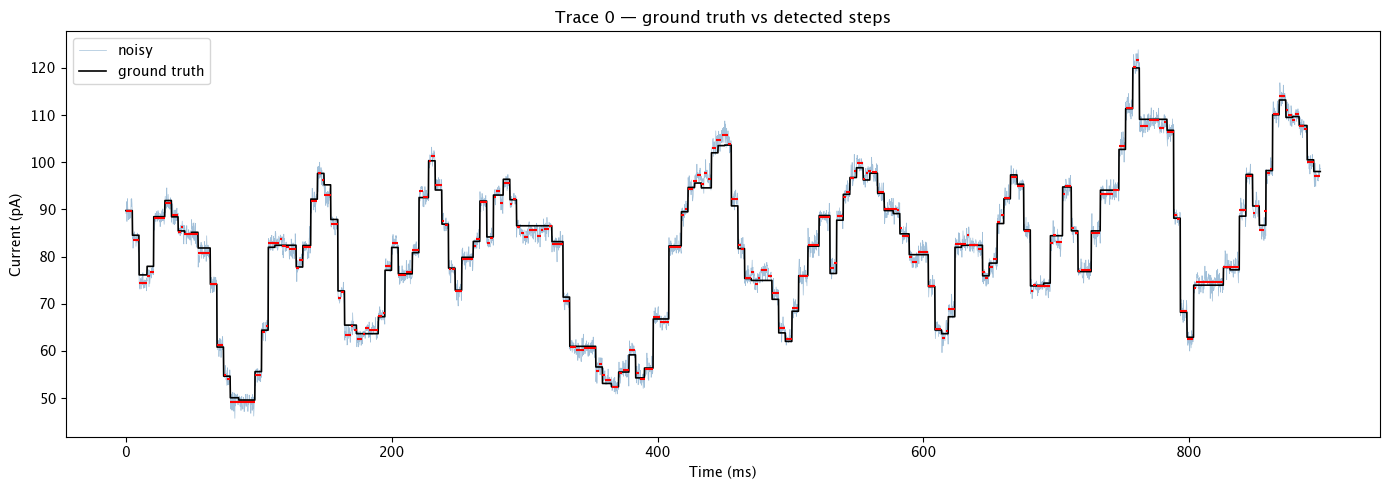

In [26]:
trace = steps.db[steps.db['trace_id'] == steps.trace_id]
time_ms = trace['time_ms'].to_numpy()
current = trace['current_pA'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 5))

# Noisy trace
ax.plot(time_ms, current, color='steelblue', linewidth=0.5, alpha=0.5, label='noisy')

# Ground truth clean levels
ax.plot(time_ms, trace['clean_pA'].to_numpy(), color='black', linewidth=1.2, label='ground truth')

# Poreflow detected steps
for _, step in steps.steps.iterrows():
    start = int(step[steps.pf.START_IDX_COL])
    end   = int(step[steps.pf.END_IDX_COL])
    ax.hlines(step[steps.pf.MEAN_COL], steps.time_ms[start], steps.time_ms[end - 1],
              color='red', linewidth=1.5)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Current (pA)')
ax.set_title(f'Trace {steps.trace_id} — ground truth vs detected steps')
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
# ground trush steps are where clean_pa changes value


trace = steps.db[steps.db['trace_id'] == steps.trace_id]
clean = trace['clean_pA'].to_numpy()
time_ms = trace['time_ms'].to_numpy()

change_idx = np.where(np.diff(clean) != 0)[0] + 1
gt_starts = np.concatenate([[0], change_idx]) # first step starts at index 0
gt_ends = np.concatenate([change_idx, [len(clean)]]) # last steps ends at final sample
gt_levels = clean[gt_starts]

gt_steps = pd.DataFrame({
    'start_idx': gt_starts,
    'end_idx': gt_ends,
    'mean': gt_levels,
    'dwell_time':(gt_ends - gt_starts)/SAMPLING_FREQ,
})

In [30]:
print(f"Ground truth: {len(gt_steps)} steps")
print(gt_steps.head(10))
print(f"\nPoreflow detected: {len(steps.steps)} steps")
print(steps.steps[['start_idx', 'end_idx', 'mean', 'dwell_time']].head(10))



Ground truth: 135 steps
   start_idx  end_idx       mean  dwell_time
0          0       25  89.751606      0.0050
1         25       50  84.528736      0.0050
2         50       80  76.118136      0.0060
3         80      105  77.935136      0.0050
4        105      147  88.462198      0.0084
5        147      172  91.886128      0.0050
6        172      197  88.431860      0.0050
7        197      222  85.441659      0.0050
8        222      247  84.779788      0.0050
9        247      272  85.151907      0.0050

Poreflow detected: 217 steps
   start_idx  end_idx       mean  dwell_time
0          0       25  89.747254      0.0050
1         25       50  83.526237      0.0050
2         50       81  74.437332      0.0062
3         81       92  75.920356      0.0022
4         92      105  76.690689      0.0026
5        105      147  88.172220      0.0084
6        147      172  91.443284      0.0050
7        172      197  88.716246      0.0050
8        197      207  85.166783      0.0020
9

In [ ]:
print("\nGround truth levels vs Poreflow detected levels:")
print(f"{'GT mean':>10}  {'PF mean':>10}  {'diff':>8}")
for gt, pf_row in zip(gt_steps['mean'], steps.steps[steps.pf.MEAN_COL]):
    print(f"{gt:>10.2f}  {pf_row:>10.2f}  {abs(gt - pf_row):>8.2f}")

In [14]:
help(changepoint.get_steps)

Help on function get_steps in module poreflow.steps.changepoint:

get_steps(i: numpy.ndarray, sfreq: float, **kwargs) -> poreflow.structures.steps.StepsDataFrame



In [15]:
import inspect
print(inspect.getsource(changepoint.get_steps))

def get_steps(i: np.ndarray, sfreq: float, **kwargs) -> pf.StepsDataFrame:
    results = get_step_features(i, **kwargs)
    return format_steps_df(*results, sfreq=sfreq)



In [16]:
print(inspect.getsource(changepoint.get_step_features))

def get_step_features(
    data: np.ndarray,
    sensitivity: float = 1,
    min_level_length: int = 2,
) -> tuple[np.ndarray, np.ndarray]:
    transitions = find_transitions(data, min_level_length, sensitivity)

    features = np.zeros((2, len(transitions) - 1))

    for j, start, stop in iter_transitions(transitions):
        features[0, j] = np.mean(data[start:stop])
        features[1, j] = np.std(data[start:stop])

    return transitions, features



/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/boxplot.py:407: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, **kwds)


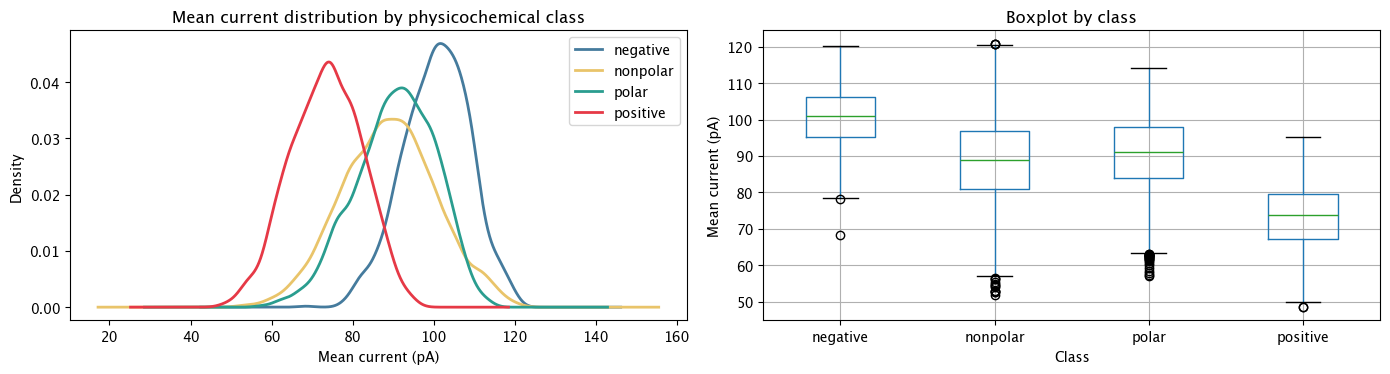

             count    mean    std    min    25%     50%     75%     max
phys_class                                                             
negative    1201.0  100.59   8.11  68.40  95.09  100.93  106.26  120.16
nonpolar    5423.0   88.94  11.62  51.75  80.87   89.01   96.79  120.86
polar       4123.0   90.50   9.83  57.18  84.00   91.16   97.85  114.26
positive    1224.0   73.40   8.67  48.50  67.24   73.73   79.64   95.08


In [17]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in df.groupby('phys_class'):
    grp['mean_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Mean current (pA)')
ax.set_title('Mean current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
df.boxplot(column='mean_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Mean current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(df.groupby('phys_class')['mean_current'].describe().round(2))

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trace_id      11971 non-null  int64  
 1   step_id       11971 non-null  int64  
 2   mean_current  11971 non-null  float64
 3   std_current   11971 non-null  float64
 4   dwell_time    11971 non-null  float64
 5   amino_acid    11971 non-null  str    
 6   phys_class    11971 non-null  str    
dtypes: float64(3), int64(2), str(2)
memory usage: 654.8 KB


/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/boxplot.py:407: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, **kwds)


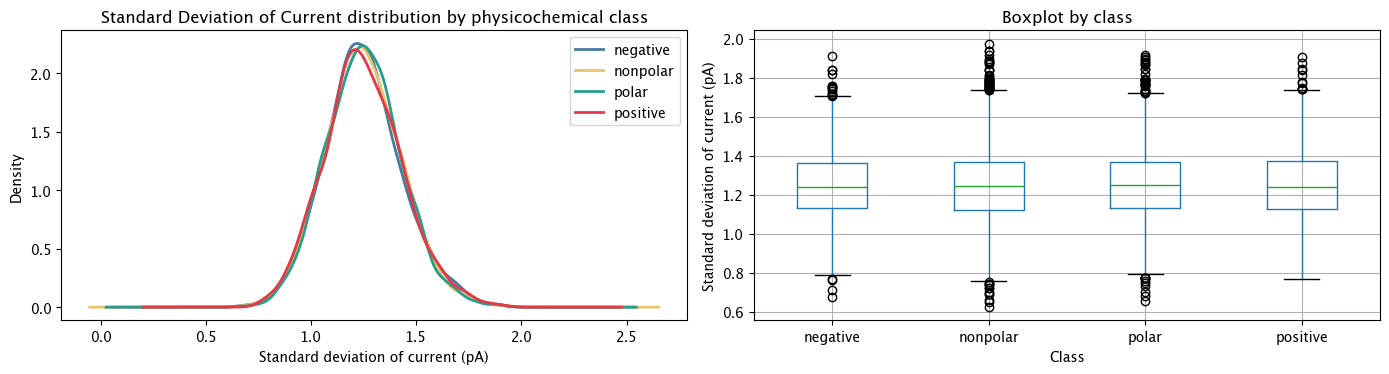

             count  mean   std   min   25%   50%   75%   max
phys_class                                                  
negative    1201.0  1.25  0.18  0.67  1.13  1.24  1.36  1.91
nonpolar    5423.0  1.25  0.18  0.62  1.12  1.24  1.37  1.98
polar       4123.0  1.25  0.18  0.66  1.13  1.25  1.37  1.92
positive    1224.0  1.25  0.19  0.77  1.13  1.24  1.37  1.91


In [19]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in df.groupby('phys_class'):
    grp['std_current'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Standard deviation of current (pA)')
ax.set_title('Standard Deviation of Current distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
df.boxplot(column='std_current', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Standard deviation of current (pA)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(df.groupby('phys_class')['std_current'].describe().round(2))

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/boxplot.py:407: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, **kwds)


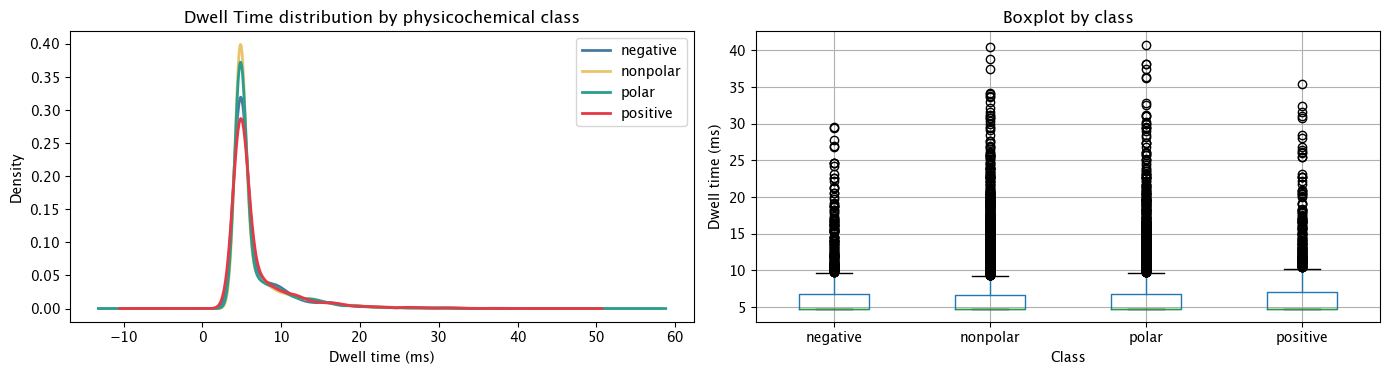

             count  mean   std  min  25%  50%  75%   max
phys_class                                              
negative    1201.0  6.58  3.64  4.8  4.8  4.8  6.8  29.6
nonpolar    5423.0  6.62  3.89  4.8  4.8  4.8  6.6  40.4
polar       4123.0  6.67  3.94  4.8  4.8  4.8  6.8  40.8
positive    1224.0  6.75  4.04  4.8  4.8  4.8  7.0  35.4


In [21]:
CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: KDE per class overlaid
ax = axes[0]
for cls, grp in df.groupby('phys_class'):
    grp['dwell_time'].plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=2)
ax.set_xlabel('Dwell time (ms)')
ax.set_title('Dwell Time distribution by physicochemical class')
ax.legend()

# Right: boxplot per class
ax = axes[1]
order = ['positive', 'negative', 'polar', 'nonpolar']
df.boxplot(column='dwell_time', by='phys_class', ax=ax,
           positions=range(len(order)), labels=order)
ax.set_xlabel('Class')
ax.set_ylabel('Dwell time (ms)')
ax.set_title('Boxplot by class')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Print summary stats
print(df.groupby('phys_class')['dwell_time'].describe().round(2))